In [90]:
import numpy as np
import pandas as pd
import glob
import xarray as xr
import os

#set current working directory
os.chdir('/home/jovyan')


DO_file_path='/shared_space/Galveston_Bay/Observed_Processed/Observed_DO_Data.csv'
DO_obs=pd.read_csv(DO_file_path)
print(DO_obs.head(3))


Salinity_file_path='/shared_space/Galveston_Bay/Observed_Processed/Observed_Salinity_Data.csv'
Salinity_obs=pd.read_csv(Salinity_file_path)
print(Salinity_obs.head(3))



temp_file_path='/shared_space/Galveston_Bay/Observed_Processed/Observed_Temp_Data.csv'
temp_obs=pd.read_csv(temp_file_path)
print(temp_obs.head(3))




              DateTime  Value        lat        lon  \
0  2010-01-04 00:00:00   12.0  29.295779 -94.918220   
1  2010-01-04 00:00:00   10.2  29.503736 -95.098957   
2  2010-01-05 09:02:00    9.7  29.723127 -94.942790   

                         source  
0                   Stream Team  
1                   Stream Team  
2  Regional Monitoring Database  
              DateTime  Value        lat        lon  \
0  2010-01-04 00:00:00   18.0  29.295779 -94.918220   
1  2010-01-05 09:02:00    2.9  29.723127 -94.942790   
2  2010-01-05 12:35:00    2.0  29.793630 -95.060914   

                         source  
0                   Stream Team  
1  Regional Monitoring Database  
2  Regional Monitoring Database  
              DateTime  Value        lat        lon  \
0  2010-01-04 00:00:00   11.0  29.503736 -95.098957   
1  2010-01-04 00:00:00    8.0  29.295779 -94.918220   
2  2010-01-05 09:02:00    7.9  29.723127 -94.942790   

                         source  
0                   Stream Team

In [91]:
# Get rid of QA/QC
DO_obs_mean = DO_obs.groupby(['DateTime','lat','lon'], as_index=False)['Value'].mean().rename(columns={'Value':'DO'})
Salinity_obs_mean = Salinity_obs.groupby(['DateTime','lat','lon'], as_index=False)['Value'].mean().rename(columns={'Value':'Salinity'})
temp_obs_mean = temp_obs.groupby(['DateTime','lat','lon'], as_index=False)['Value'].mean().rename(columns={'Value':'temp'})


In [125]:
# innter merge 
merged_df = pd.merge(DO_obs_mean, Salinity_obs_mean, on=['DateTime','lat','lon'], how='inner')
merged_df = pd.merge(merged_df, temp_obs_mean, on=['DateTime','lat','lon'], how='inner')

# Reorder columns
merged_df = merged_df[['DateTime', 'lat', 'lon', 'DO', 'Salinity', 'temp']]
merged_df['DateTime'] = pd.to_datetime(merged_df['DateTime'])

merged_df['DOY'] = merged_df['DateTime'].dt.dayofyear

merged_df['Month'] = merged_df['DateTime'].dt.month

print(merged_df.head())
print("Number of merged rows:", len(merged_df))

             DateTime        lat        lon    DO  Salinity  temp  DOY  Month
0 2010-01-04 00:00:00  29.295779 -94.918220  12.0      18.0   8.0    4      1
1 2010-01-05 09:02:00  29.723127 -94.942790   9.7       2.9   7.9    5      1
2 2010-01-05 12:35:00  29.793630 -95.060914  10.5       2.0   9.6    5      1
3 2010-01-07 00:00:00  29.591217 -95.042331  10.5       6.8   9.5    7      1
4 2010-01-13 09:50:00  29.723127 -94.942790  11.1       5.7   6.7   13      1
Number of merged rows: 935


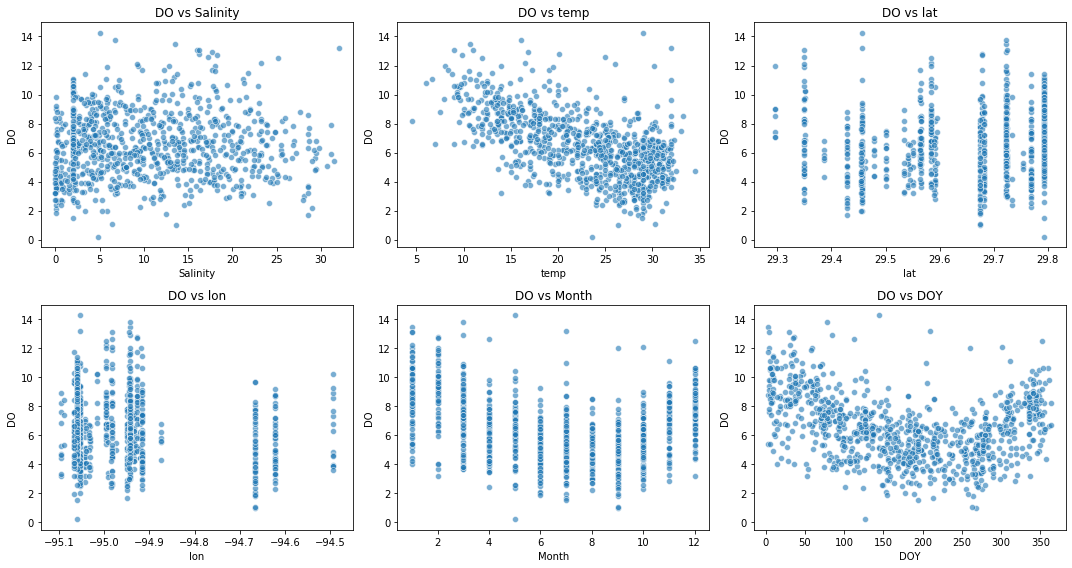

In [126]:
import matplotlib.pyplot as plt
import seaborn as sns

predictors = ['Salinity', 'temp', 'lat', 'lon', 'Month',"DOY"]

plt.figure(figsize=(15, 8))

for i, col in enumerate(predictors, 1):
    plt.subplot(2, 3, i)  # 2 rows, 3 columns layout
    sns.scatterplot(x=merged_df[col], y=merged_df['DO'], alpha=0.6)
    plt.xlabel(col)
    plt.ylabel('DO')
    plt.title(f'DO vs {col}')

plt.tight_layout()
plt.show()

n_estimators=10, Train MSE=0.589, Test MSE=4.262, Train R2=0.880, Test R2=0.307
n_estimators=50, Train MSE=0.425, Test MSE=4.301, Train R2=0.913, Test R2=0.301
n_estimators=100, Train MSE=0.413, Test MSE=4.278, Train R2=0.916, Test R2=0.305
n_estimators=200, Train MSE=0.402, Test MSE=4.336, Train R2=0.918, Test R2=0.295
n_estimators=300, Train MSE=0.403, Test MSE=4.357, Train R2=0.918, Test R2=0.292
n_estimators=500, Train MSE=0.402, Test MSE=4.343, Train R2=0.918, Test R2=0.294


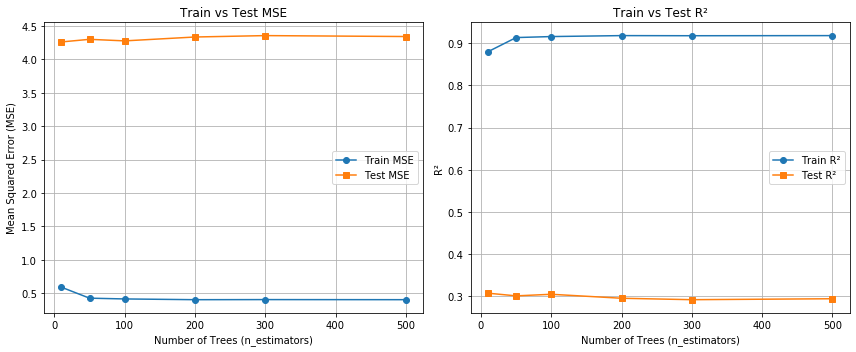

In [147]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Predictors and target
X = merged_df[['Salinity', 'temp', 'DOY']]
y = merged_df['DO']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# Define range of trees
n_trees = [10, 50, 100, 200, 300, 500]

train_mse_list, test_mse_list = [], []
train_r2_list, test_r2_list = [], []

for n in n_trees:
    rf = RandomForestRegressor(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    
    # Predict
    y_train_pred = rf.predict(X_train)
    y_test_pred = rf.predict(X_test)
    
    # MSE
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    train_mse_list.append(train_mse)
    test_mse_list.append(test_mse)
    
    # R^2
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    train_r2_list.append(train_r2)
    test_r2_list.append(test_r2)
    
    print(f"n_estimators={n}, Train MSE={train_mse:.3f}, Test MSE={test_mse:.3f}, Train R2={train_r2:.3f}, Test R2={test_r2:.3f}")

# Plot MSE
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(n_trees, train_mse_list, marker='o', label='Train MSE')
plt.plot(n_trees, test_mse_list, marker='s', label='Test MSE')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Train vs Test MSE')
plt.legend()
plt.grid(True)

# Plot R^2
plt.subplot(1,2,2)
plt.plot(n_trees, train_r2_list, marker='o', label='Train R²')
plt.plot(n_trees, test_r2_list, marker='s', label='Test R²')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('R²')
plt.title('Train vs Test R²')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


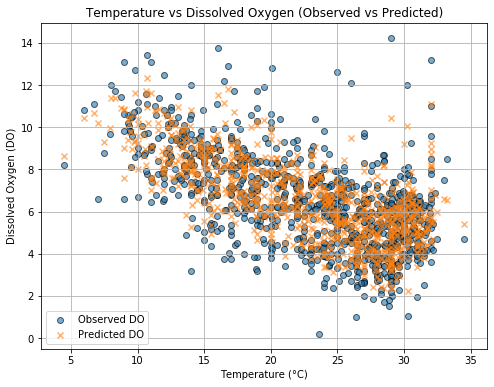

In [148]:
import matplotlib.pyplot as plt

# Predict DO using the fitted Random Forest model
y_pred = rf_final.predict(merged_df[['Salinity', 'temp', 'Month', 'lat', 'lon']])

plt.figure(figsize=(8,6))

# Plot observed DO
plt.scatter(merged_df['temp'], merged_df['DO'], alpha=0.6, edgecolor='k', label='Observed DO')

# Plot predicted DO
plt.scatter(merged_df['temp'], y_pred, alpha=0.6, edgecolor='r', label='Predicted DO', marker='x')

plt.xlabel('Temperature (°C)')
plt.ylabel('Dissolved Oxygen (DO)')
plt.title('Temperature vs Dissolved Oxygen (Observed vs Predicted)')
plt.legend()
plt.grid(True)
plt.show()


In [130]:
temp_obs_wqp = temp_obs[temp_obs['source'] == 'Water Quality Portal'].copy()

# Sort by DateTime ascending
temp_obs_wqp = temp_obs_wqp.sort_values(by='DateTime', ascending=True)

print(temp_obs_wqp.head())

salinity_obs_wqp = Salinity_obs[Salinity_obs['source'] == 'Water Quality Portal'].copy()

# Sort by DateTime ascending
salinity_obs_wqp = salinity_obs_wqp.sort_values(by='DateTime', ascending=True)

print(salinity_obs_wqp.head())



                 DateTime  Value      lat      lon                source
1720  2018-01-04 00:00:00    7.4  29.5225 -95.0789  Water Quality Portal
1721  2018-01-05 00:00:00    8.1  29.7700 -94.9161  Water Quality Portal
1722  2018-01-05 00:00:00    8.0  29.7700 -94.9161  Water Quality Portal
1723  2018-01-05 00:00:00   11.4  29.7700 -94.9161  Water Quality Portal
1724  2018-01-05 00:00:00    8.5  29.7700 -94.9161  Water Quality Portal
                DateTime  Value      lat      lon                source
971  2018-01-23 00:00:00   18.1  29.6184 -94.8608  Water Quality Portal
991  2018-01-23 00:00:00   19.3  29.5237 -94.9888  Water Quality Portal
989  2018-01-23 00:00:00   19.8  29.5962 -94.8806  Water Quality Portal
988  2018-01-23 00:00:00   20.2  29.5237 -94.9888  Water Quality Portal
987  2018-01-23 00:00:00   19.0  29.5566 -94.9045  Water Quality Portal


In [141]:
# Round lat/lon for matching
temp_obs_wqp['lat_r'] = temp_obs_wqp['lat'].round(4)
temp_obs_wqp['lon_r'] = temp_obs_wqp['lon'].round(4)
salinity_obs_wqp['lat_r'] = salinity_obs_wqp['lat'].round(4)
salinity_obs_wqp['lon_r'] = salinity_obs_wqp['lon'].round(4)

# Merge with full outer join
temp_salinity_wqp = pd.merge(
    temp_obs_wqp[['DateTime','lat_r','lon_r','Value','source']], 
    salinity_obs_wqp[['DateTime','lat_r','lon_r','Value','source']],
    on=['DateTime','lat_r','lon_r'],
    how='outer',
    suffixes=('_temp','_salinity'),
    indicator=True  # tells us if row exists in left/right/both
)

# Create a new source column
def merge_source(row):
    if row['_merge'] == 'both':
        return 'both'
    elif row['_merge'] == 'left_only':
        return 'temp'
    else:  # right_only
        return 'salinity'

temp_salinity_wqp['new_source'] = temp_salinity_wqp.apply(merge_source, axis=1)

# Rename values columns
temp_salinity_wqp = temp_salinity_wqp.rename(columns={'Value_temp':'temp', 'Value_salinity':'Salinity', 
                                                      'lat_r':'lat','lon_r':'lon'})

# Optional: keep only relevant columns
temp_salinity_wqp = temp_salinity_wqp[['DateTime','lat','lon','temp','Salinity','new_source']]


middle_bay_temp_salinity=temp_salinity_wqp[temp_salinity_wqp['new_source']=='both']

middle_bay_temp_salinity.head(5)

,DateTime,lat,lon,temp,Salinity,new_source
27,2018-01-23 00:00:00,29.5566,-94.9045,9.2,19.0,both
28,2018-01-23 00:00:00,29.5566,-94.9045,9.2,20.8,both
29,2018-01-23 00:00:00,29.5566,-94.9045,9.2,20.0,both
30,2018-01-23 00:00:00,29.5566,-94.9045,9.0,19.0,both
31,2018-01-23 00:00:00,29.5566,-94.9045,9.0,20.8,both


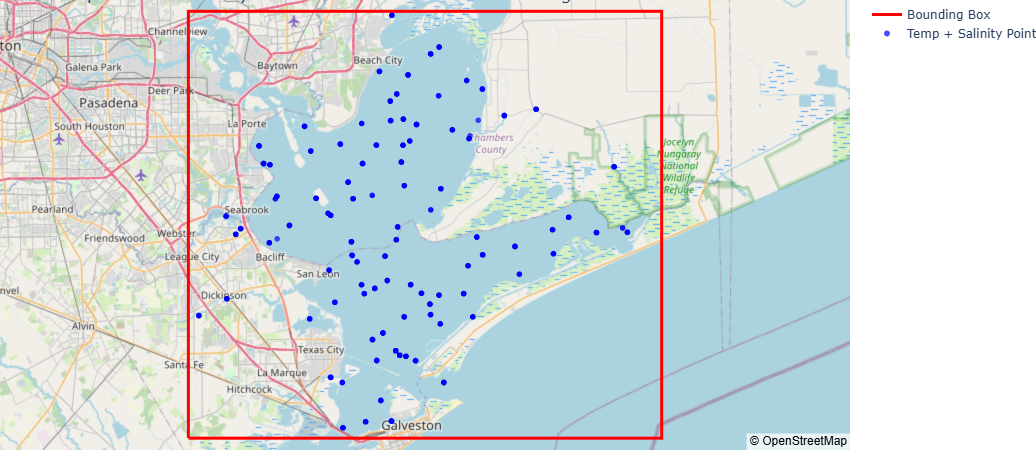

In [142]:
import plotly.graph_objects as go

# Bounding box
extent = [-95.1, -94.45, 29.29, 29.8]
lons = [extent[0], extent[1], extent[1], extent[0], extent[0]]
lats = [extent[2], extent[2], extent[3], extent[3], extent[2]]

# Center of the bounding box
center_lon = (extent[0] + extent[1]) / 2
center_lat = (extent[2] + extent[3]) / 2

fig = go.Figure()

# Add bounding box
fig.add_trace(go.Scattermapbox(
    lon=lons,
    lat=lats,
    mode='lines',
    line=dict(width=3, color='red'),
    name='Bounding Box'
))

# Add temp + salinity points
fig.add_trace(go.Scattermapbox(
    lon=middle_bay_temp_salinity['lon'],  # replace with your longitude column
    lat=middle_bay_temp_salinity['lat'],  # replace with your latitude column
    mode='markers',
    marker=dict(size=6, color='blue', opacity=0.7),
    name='Temp + Salinity Points'
))

# Update layout
fig.update_layout(
    mapbox=dict(
        style="open-street-map",
        center=dict(lat=center_lat, lon=center_lon),
        zoom=9
    ),
    margin={"r":0,"t":0,"l":0,"b":0},
    title="Temperature + Salinity Measurement Points within Bounding Box"
)

fig.show()


In [143]:
middle_bay_temp_salinity['DateTime'] = pd.to_datetime(middle_bay_temp_salinity['DateTime'])
middle_bay_temp_salinity['DOY'] = middle_bay_temp_salinity['DateTime'].dt.dayofyear
middle_bay_temp_salinity.head(5)



/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy



,DateTime,lat,lon,temp,Salinity,new_source,DOY
27,2018-01-23,29.5566,-94.9045,9.2,19.0,both,23
28,2018-01-23,29.5566,-94.9045,9.2,20.8,both,23
29,2018-01-23,29.5566,-94.9045,9.2,20.0,both,23
30,2018-01-23,29.5566,-94.9045,9.0,19.0,both,23
31,2018-01-23,29.5566,-94.9045,9.0,20.8,both,23


In [150]:
X_new = middle_bay_temp_salinity[['Salinity', 'temp', 'DOY', 'lat', 'lon']]

# Predict DO using the trained Random Forest
middle_bay_temp_salinity['Predicted_DO'] = rf_final.predict(X_new)

# Inspect results
middle_bay_temp_salinity.head(5)

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy



,DateTime,lat,lon,temp,Salinity,new_source,DOY,Predicted_DO
27,2018-01-23,29.5566,-94.9045,9.2,19.0,both,23,9.149207
28,2018-01-23,29.5566,-94.9045,9.2,20.8,both,23,9.086007
29,2018-01-23,29.5566,-94.9045,9.2,20.0,both,23,9.109207
30,2018-01-23,29.5566,-94.9045,9.0,19.0,both,23,9.156907
31,2018-01-23,29.5566,-94.9045,9.0,20.8,both,23,9.093707


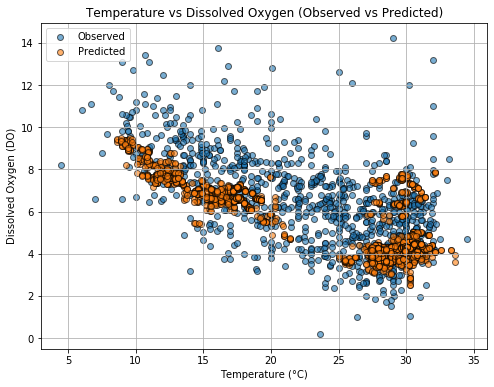

In [151]:
import matplotlib.pyplot as plt

# Step 1: Prepare observed data
observed_df = merged_df[['temp', 'DO']].copy()
observed_df['type'] = 'Observed'

# Step 2: Prepare predicted data
predicted_df = middle_bay_temp_salinity[['temp', 'Predicted_DO']].copy()
predicted_df = predicted_df.rename(columns={'Predicted_DO':'DO'})
predicted_df['type'] = 'Predicted'

# Step 3: Combine datasets
combined_df = pd.concat([observed_df, predicted_df], ignore_index=True)

# Step 4: Plot
plt.figure(figsize=(8,6))
for t in combined_df['type'].unique():
    subset = combined_df[combined_df['type'] == t]
    plt.scatter(subset['temp'], subset['DO'], alpha=0.6, label=t, edgecolor='k')

plt.xlabel('Temperature (°C)')
plt.ylabel('Dissolved Oxygen (DO)')
plt.title('Temperature vs Dissolved Oxygen (Observed vs Predicted)')
plt.legend()
plt.grid(True)
plt.show()


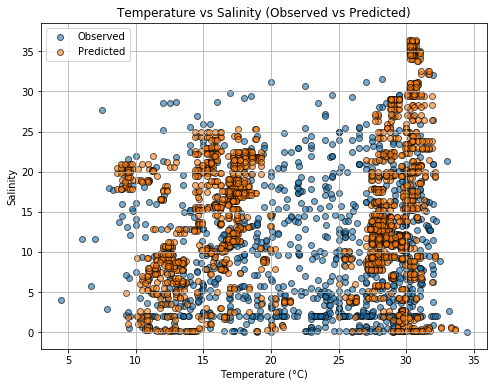

In [152]:
import matplotlib.pyplot as plt

# Step 1: Prepare observed data
observed_df = merged_df[['temp', 'Salinity']].copy()
observed_df['type'] = 'Observed'

# Step 2: Prepare predicted data
predicted_df = middle_bay_temp_salinity[['temp', 'Salinity']].copy()
predicted_df['type'] = 'Predicted'

# Step 3: Combine datasets
combined_df = pd.concat([observed_df, predicted_df], ignore_index=True)

# Step 4: Plot
plt.figure(figsize=(8,6))
for t in combined_df['type'].unique():
    subset = combined_df[combined_df['type'] == t]
    plt.scatter(subset['temp'], subset['Salinity'], alpha=0.6, label=t, edgecolor='k')

plt.xlabel('Temperature (°C)')
plt.ylabel('Salinity')
plt.title('Temperature vs Salinity (Observed vs Predicted)')
plt.legend()
plt.grid(True)
plt.show()


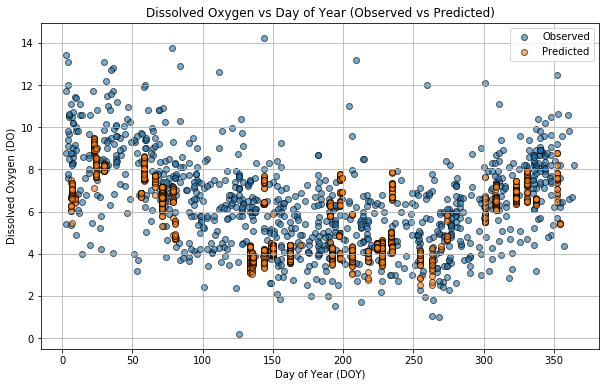

In [154]:
import matplotlib.pyplot as plt

# Ensure DOY exists
for df in [merged_df, middle_bay_temp_salinity]:
    if 'DOY' not in df.columns:
        df['DOY'] = pd.to_datetime(df['DateTime']).dt.dayofyear

# Step 1: Prepare observed data
observed_df = merged_df[['DOY', 'DO']].copy()
observed_df['type'] = 'Observed'

# Step 2: Prepare predicted data
predicted_df = middle_bay_temp_salinity[['DOY', 'Predicted_DO']].copy()
predicted_df = predicted_df.rename(columns={'Predicted_DO':'DO'})
predicted_df['type'] = 'Predicted'

# Step 3: Combine datasets
combined_df = pd.concat([observed_df, predicted_df], ignore_index=True)

# Step 4: Plot
plt.figure(figsize=(10,6))
for t in combined_df['type'].unique():
    subset = combined_df[combined_df['type'] == t]
    plt.scatter(subset['DOY'], subset['DO'], alpha=0.6, label=t, edgecolor='k')

plt.xlabel('Day of Year (DOY)')
plt.ylabel('Dissolved Oxygen (DO)')
plt.title('Dissolved Oxygen vs Day of Year (Observed vs Predicted)')
plt.legend()
plt.grid(True)
plt.show()


In [156]:
# Step 1: Prepare observed data
observed_df = merged_df[['DateTime','lat','lon','DO']].copy()
observed_df['type'] = 'Observed'

# Step 2: Prepare predicted data
predicted_df = middle_bay_temp_salinity[['DateTime','lat','lon', 'Predicted_DO']].copy()
predicted_df = predicted_df.rename(columns={'Predicted_DO':'DO'})
predicted_df['type'] = 'Predicted'

# Step 3: Combine datasets
combined_df = pd.concat([observed_df, predicted_df], ignore_index=True)
combined_df.head()


,DateTime,lat,lon,DO,type
0,2010-01-04 00:00:00,29.295779,-94.918220,12.0,Observed
1,2010-01-05 09:02:00,29.723127,-94.942790,9.7,Observed
2,2010-01-05 12:35:00,29.793630,-95.060914,10.5,Observed
3,2010-01-07 00:00:00,29.591217,-95.042331,10.5,Observed
4,2010-01-13 09:50:00,29.723127,-94.942790,11.1,Observed


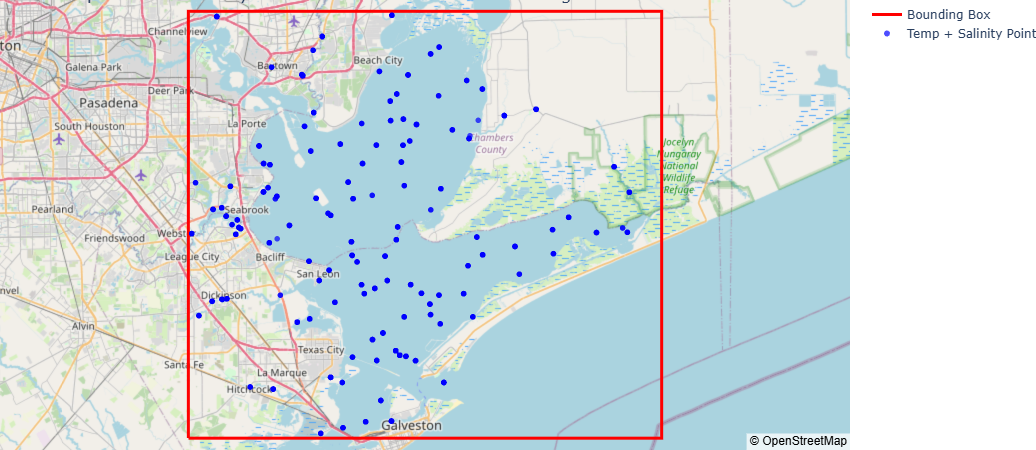

In [157]:
import plotly.graph_objects as go

# Bounding box
extent = [-95.1, -94.45, 29.29, 29.8]
lons = [extent[0], extent[1], extent[1], extent[0], extent[0]]
lats = [extent[2], extent[2], extent[3], extent[3], extent[2]]

# Center of the bounding box
center_lon = (extent[0] + extent[1]) / 2
center_lat = (extent[2] + extent[3]) / 2

fig = go.Figure()

# Add bounding box
fig.add_trace(go.Scattermapbox(
    lon=lons,
    lat=lats,
    mode='lines',
    line=dict(width=3, color='red'),
    name='Bounding Box'
))

# Add temp + salinity points
fig.add_trace(go.Scattermapbox(
    lon=combined_df['lon'],  # replace with your longitude column
    lat=combined_df['lat'],  # replace with your latitude column
    mode='markers',
    marker=dict(size=6, color='blue', opacity=0.7),
    name='Temp + Salinity Points'
))

# Update layout
fig.update_layout(
    mapbox=dict(
        style="open-street-map",
        center=dict(lat=center_lat, lon=center_lon),
        zoom=9
    ),
    margin={"r":0,"t":0,"l":0,"b":0},
    title="Temperature + Salinity Measurement Points within Bounding Box"
)

fig.show()


In [161]:


combined_df.to_csv('/shared_space/Galveston_Bay/Observed_Processed/Observed_DO_Data_w_predictions.csv', index=False)